In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [5]:
df = pd.read_csv('telco_churn_encoded.csv')
df.head()

,Gender,Age,Married,Dependents,Number of Dependents,Referred a Friend,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,...,Offer_Offer D,Offer_Offer E,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check,Churn
0,1,78,0,0,0,0,0.0,1,0,0.00,...,0,0,1,0,0,0,0,0,0,1
1,0,74,1,1,0,1,1.0,8,1,48.85,...,0,1,0,1,0,0,0,1,0,1
2,1,71,0,1,0,0,0.0,18,1,11.33,...,1,0,0,1,0,0,0,0,0,1
3,0,78,1,1,0,1,1.0,25,1,19.76,...,0,0,0,1,0,0,0,0,0,1
4,0,80,1,1,0,1,1.0,37,1,6.33,...,0,0,0,1,0,0,0,0,0,1


In [6]:
# XGBOOST

# target
y = df['Churn']

# features
X = df.drop(columns=['Churn'])

In [10]:
X.columns

Index(['Gender', 'Age', 'Married', 'Dependents', 'Number of Dependents',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Avg Monthly GB Download', 'Online Security',
       'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
       'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data',
       'Paperless Billing', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'CLTV', 'Urban_Rural_Town', 'Urban_Rural_City',
       'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D',
       'Offer_Offer E', 'Internet Type_DSL', 'Internet Type_Fiber Optic',
       'Internet Type_No Internet', 'Contract_One Year', 'Contract_Two Year',
       'Payment Method_Credit Card', 'Payment Method_Mailed Check'],
      dtype='object')

In [11]:
X = X.drop(columns=[
    'CustomerID',
    'Churn Reason',
    'Churn Category'
], errors='ignore')

In [12]:
binary_map = {
    'Yes': 1,
    'No': 0,
    'Male': 1,
    'Female': 0
}

binary_cols = [
    'Gender', 'Married', 'Dependents', 'Referred a Friend',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing'
]

for col in binary_cols:
    X[col] = X[col].map(binary_map)

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             0 non-null      float64
 1   Age                                7043 non-null   int64  
 2   Married                            0 non-null      float64
 3   Dependents                         0 non-null      float64
 4   Number of Dependents               7043 non-null   int64  
 5   Referred a Friend                  0 non-null      float64
 6   Number of Referrals                7043 non-null   float64
 7   Tenure in Months                   7043 non-null   int64  
 8   Phone Service                      0 non-null      float64
 9   Avg Monthly Long Distance Charges  7043 non-null   float64
 10  Multiple Lines                     0 non-null      float64
 11  Internet Service                   0 non-null      float

Everything is numeric, so we are ready for modelling

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Why stratify=y?
Because churn data is usually imbalanced, and this keeps the same churn proportion in train and test.

In [15]:
!pip install xgboost

In [16]:
from xgboost import XGBClassifier

model_cltv = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [17]:
model_cltv.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
y_pred_cltv = model_cltv.predict(X_test)

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_cltv))
print(classification_report(y_test, y_pred_cltv))

[[839 196]
 [ 73 301]]
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1035
           1       0.61      0.80      0.69       374

    accuracy                           0.81      1409
   macro avg       0.76      0.81      0.78      1409
weighted avg       0.84      0.81      0.82      1409



                       Feature  Importance
40           Contract_Two Year    0.368264
39           Contract_One Year    0.180389
6          Number of Referrals    0.069444
37   Internet Type_Fiber Optic    0.061934
38   Internet Type_No Internet    0.038511
41  Payment Method_Credit Card    0.032265
7             Tenure in Months    0.022573
22              Monthly Charge    0.020350
12     Avg Monthly GB Download    0.017114
1                          Age    0.016551


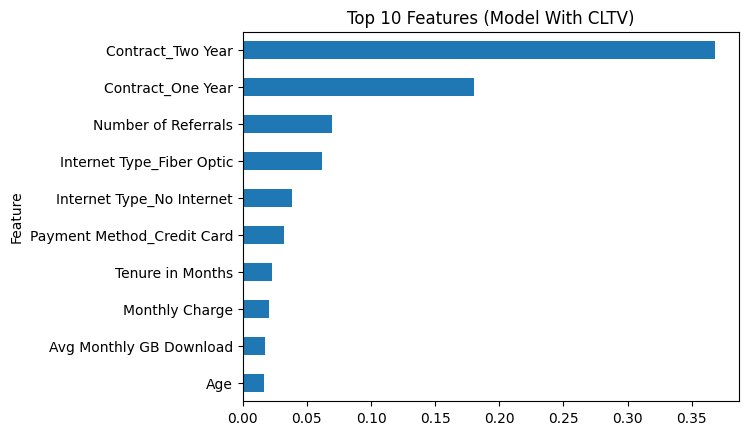

In [20]:
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_cltv.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

importance_df.head(10).sort_values(by='Importance').plot(
    x='Feature', y='Importance', kind='barh', legend=False
)
plt.title('Top 10 Features (Model With CLTV)')
plt.show()

Results of Model version 1:
Recall = 0.80, Out of all customers who actually churned, we correctly caught 80% of them

Precision = 0.61, When the model says someone will churn, it is correct 61% of the time.

Long contracts: low churn
Short contracts: high churn

In [22]:
# threshhold tuning REMOVE
y_probs = model_cltv.predict_proba(X_test)[:,1]
y_pred_03 = (y_probs > 0.3).astype(int)

print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.96      0.72      0.82      1035
           1       0.54      0.91      0.68       374

    accuracy                           0.77      1409
   macro avg       0.75      0.82      0.75      1409
weighted avg       0.85      0.77      0.79      1409



Lowering the classification threshold from 0.5 to 0.3 increased recall from 80% to 91%, significantly improving the model’s ability to identify customers at risk of churning. Although precision decreased, this tradeoff is acceptable in a churn context where missing at-risk customers is more costly than incorrectly flagging them.

In [23]:
for t in [0.4, 0.45, 0.5]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.94      0.76      0.84      1035
           1       0.57      0.87      0.69       374

    accuracy                           0.79      1409
   macro avg       0.76      0.82      0.77      1409
weighted avg       0.85      0.79      0.80      1409


Threshold: 0.45
              precision    recall  f1-score   support

           0       0.94      0.78      0.85      1035
           1       0.59      0.86      0.70       374

    accuracy                           0.80      1409
   macro avg       0.76      0.82      0.78      1409
weighted avg       0.85      0.80      0.81      1409


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1035
           1       0.61      0.80      0.69       374

    accuracy                           0.81      1409
   macro avg       0.76      0.81      0.78      1409
weighted avg       0.84  

In [24]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0.1, 0.9, 50)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_probs > t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_t = thresholds[np.argmax(f1_scores)]
print("Best threshold:", best_t)

Best threshold: 0.44285714285714284


We evaluated multiple classification thresholds and selected a threshold of approximately 0.44, which maximized the F1-score. This provided the best balance between precision (0.59) and recall (0.86), ensuring the model effectively identifies churners while limiting false positives.

XGBoost w/out CLTV

In [25]:
X_no_cltv = X.drop(columns=['CLTV'], errors='ignore')

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_no_cltv, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_no_cltv = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model_no_cltv.fit(X_train, y_train)

y_probs = model_no_cltv.predict_proba(X_test)[:,1]

# use SAME threshold (important!)
y_pred = (y_probs > 0.44).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1035
           1       0.58      0.85      0.69       374

    accuracy                           0.80      1409
   macro avg       0.76      0.81      0.77      1409
weighted avg       0.84      0.80      0.81      1409



The model’s performance remained nearly unchanged after removing CLTV, suggesting that CLTV was not a major driver of predictive performance. Because CLTV may contain information derived from future customer behavior, excluding it produces a cleaner and more defensible churn model with little loss in predictive ability.

[[809 226]
 [ 57 317]]


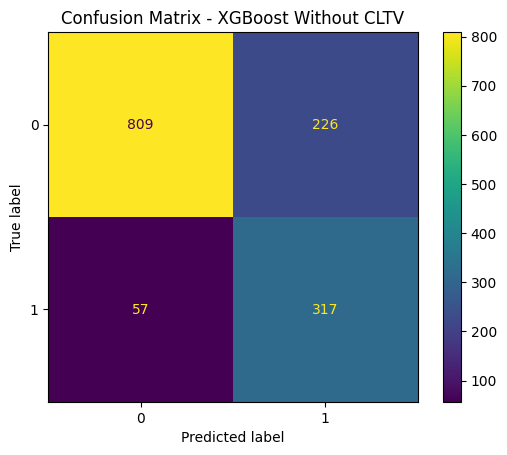

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - XGBoost Without CLTV")
plt.show()

In [28]:
importance_df = pd.DataFrame({
    'Feature': X_no_cltv.columns,
    'Importance': model_no_cltv.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                       Feature  Importance
39           Contract_Two Year    0.381430
38           Contract_One Year    0.164093
37   Internet Type_No Internet    0.064506
36   Internet Type_Fiber Optic    0.060926
6          Number of Referrals    0.056264
40  Payment Method_Credit Card    0.032944
7             Tenure in Months    0.021423
22              Monthly Charge    0.018941
23               Total Charges    0.017534
1                          Age    0.016737


An XGBoost classifier was developed to predict customer churn. Because churn data is imbalanced, performance was evaluated using precision, recall, and F1-score rather than accuracy alone. Threshold tuning was used to improve the balance between identifying churners and limiting false positives. A threshold of approximately 0.44 gave the best balance. The final model without CLTV achieved a churn precision of 0.58, recall of 0.85, and F1-score of 0.69. Removing CLTV caused almost no performance loss, so the final model excluded it to avoid relying on a potentially future-based variable.

In [29]:
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])
print(scale)

2.768561872909699


In [30]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.1],
    'n_estimators': [200, 300, 400],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale, eval_metric='logloss'),
    param_grid,
    scoring='f1',   # IMPORTANT
    cv=3,
    verbose=1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
{'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}


In [32]:
best_model = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.03,
    max_depth=6,
    n_estimators=200,
    subsample=0.7,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

In [33]:
best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
y_pred_best = best_model.predict(X_test)

In [35]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[845 190]
 [ 69 305]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1035
           1       0.62      0.82      0.70       374

    accuracy                           0.82      1409
   macro avg       0.77      0.82      0.78      1409
weighted avg       0.84      0.82      0.82      1409



An XGBoost model was developed to predict customer churn. To address class imbalance, class weighting was applied. Hyperparameter tuning using GridSearchCV improved model performance by optimizing tree depth, learning rate, and sampling parameters. The final model achieved a precision of 0.62, recall of 0.82, and F1-score of 0.70 for the churn class. Compared to the initial model, precision improved while maintaining high recall, resulting in a more balanced and reliable model. CLTV was removed due to its potential to include future information, and its removal had minimal impact on performance, confirming that the model remains robust without it.
Customers with short-term contracts and higher monthly charges are more likely to churn. Retention strategies should focus on incentivizing long-term contracts and targeting high-risk customers early.

In [36]:
# trying early stopping
from xgboost import XGBClassifier

early_model = XGBClassifier(
    colsample_bytree=0.7,
    learning_rate=0.03,
    max_depth=6,
    n_estimators=400,
    subsample=0.7,
    scale_pos_weight=scale,
    eval_metric='logloss',
    random_state=42
)

In [37]:
early_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_early = early_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_early))
print(classification_report(y_test, y_pred_early))

[[864 171]
 [ 79 295]]
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1035
           1       0.63      0.79      0.70       374

    accuracy                           0.82      1409
   macro avg       0.77      0.81      0.79      1409
weighted avg       0.84      0.82      0.83      1409



Early stopping was tested to reduce overfitting, but it did not improve overall model performance. While precision increased slightly, recall decreased, resulting in no improvement in F1-score. Therefore, early stopping was not included in the final model.

In [40]:
# weight tuing
weights_to_try = [2.0, 2.5, 2.77, 3.0, 3.5]

for w in weights_to_try:
    model = XGBClassifier(
        colsample_bytree=0.7,
        learning_rate=0.03,
        max_depth=6,
        n_estimators=200,
        subsample=0.7,
        scale_pos_weight=w,
        eval_metric='logloss',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n===== weight = {w} =====")
    print(classification_report(y_test, y_pred))


===== weight = 2.0 =====
              precision    recall  f1-score   support

           0       0.91      0.85      0.88      1035
           1       0.65      0.76      0.70       374

    accuracy                           0.83      1409
   macro avg       0.78      0.81      0.79      1409
weighted avg       0.84      0.83      0.83      1409


===== weight = 2.5 =====
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1035
           1       0.63      0.79      0.70       374

    accuracy                           0.82      1409
   macro avg       0.77      0.81      0.79      1409
weighted avg       0.84      0.82      0.83      1409


===== weight = 2.77 =====
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1035
           1       0.62      0.82      0.70       374

    accuracy                           0.82      1409
   macro avg       0.77      0.82      0.79      

Since the primary goal of this model is to identify customers likely to churn, recall was prioritized over precision. Increasing the scale_pos_weight parameter allowed the model to better identify churn cases. A value of 3.0 provided a strong recall of 0.83 while maintaining acceptable precision, making it the best choice for this objective.